# Chapter: Data Leakage
## Feature Engineering & MLOps

**A model that scores 99% in validation and then falls apart in production almost always has
one root cause: data leakage.** This notebook teaches you how to spot it, fix it, and never
accidentally create it again.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain what data leakage is, in plain language, to someone with no ML background
- Identify **target leakage**, **look-ahead bias**, and **preprocessing leakage** in a real dataset
- Demonstrate, with your own numbers, how a leaked feature produces an unrealistically good
  validation score
- Correctly order a preprocessing + train/test split pipeline to avoid train-test contamination
- Apply a leakage detection checklist to any new dataset you're handed
- Answer common data leakage interview questions with confidence

## Real-World Problem

You work at a telecom company. Customers are leaving (**churning**) at a worrying rate, and
leadership wants a model that flags customers who are LIKELY to churn NEXT MONTH, so the retention
team can call them before they cancel.

- **Raw data available:** customer account records — how long they've been a customer, what
  they pay, what contract they're on, how many times they've called support.
- **Target:** `churn` — did this customer cancel their service? (1 = yes, 0 = no)
- **Features we might create:** tenure, monthly charges, contract type, support call frequency.
- **Why the business cares:** every customer the retention team can save before they cancel is
  revenue the company keeps. But if the model turns out to be useless in practice (even though
  it looked great in testing), the retention team wastes time chasing customers who were never
  actually going to cancel — or worse, misses the ones who really were.

This notebook is about exactly how a model can look great in testing and still be completely
useless in practice — and how to make sure that never happens to you.

## Why Do We Need This Concept?

**Analogy:** Data leakage is like **giving a student the answer key before the exam.** The
student aces the exam — a perfect score! But that score tells you NOTHING about whether the
student actually learned the material. The moment you give them a DIFFERENT exam (without the
answer key), their real performance is exposed, and it's often much worse than the "perfect
score" led you to believe.

A machine learning model works the same way. If a feature in your training data secretly
contains information that only exists BECAUSE the outcome already happened (the "answer key"),
the model doesn't learn to PREDICT the outcome — it just learns to read the answer key. Your
validation score looks fantastic. Then you deploy the model, where that answer key isn't
available yet (because the real-world outcome hasn't happened), and the model's performance
collapses.

**What happens if we don't guard against this?**
- Teams ship models that looked excellent in testing and fail silently in production
- Money, engineering time, and trust get wasted chasing a model that was never real
- The failure is often only discovered MONTHS later, when it's expensive to unwind

## Concept Intuition

Data leakage happens whenever information that would **NOT actually be available at the moment
you need to make a prediction** sneaks into your training data.

```
PREDICTION TIME:                    "Will this customer churn NEXT month?"
                                              |
                                     (you only know: tenure, charges,
                                      contract, support calls SO FAR)
                                              |
                                              v
                                        [ YOUR MODEL ]
                                              |
                                              v
                                   prediction: churn or not?
```

A leaked feature is something that could ONLY exist **AFTER** the answer is already known —
like `cancellation_date`, which by definition does not exist until a customer has already
cancelled.

| | Legitimate feature | Leaked feature |
|---|---|---|
| **When is it known?** | Before the outcome happens | Only after (or because of) the outcome |
| **Example** | `tenure_months`, `support_calls` | `cancellation_date`, `final_bill_amount` |
| **Available at prediction time?** | Yes | No |
| **The ONE test that catches it** | — | *"Could this feature have existed at the moment I need to make this prediction?"* |

That question in the last row is the single most important mental model in this entire
notebook. Every example, every exercise, and every interview question below comes back to it.

## Tiny Manual Example

Before touching any code, let's work through 8 tiny customer records BY HAND — small enough
to reason about on paper.

| customer | tenure_months | support_calls | cancellation_date | churn |
|---|---|---|---|---|
| C1 | 34 | 1 | *(blank)* | 0 |
| C2 | 3  | 5 | 2024-03-11 | 1 |
| C3 | 51 | 0 | *(blank)* | 0 |
| C4 | 8  | 4 | 2024-01-22 | 1 |
| C5 | 22 | 2 | *(blank)* | 0 |
| C6 | 2  | 6 | 2024-05-02 | 1 |
| C7 | 44 | 1 | *(blank)* | 0 |
| C8 | 6  | 3 | 2024-02-14 | 1 |

**Question: without even looking at `tenure_months` or `support_calls`, can you predict
`churn` perfectly just from one column?**

Look at `cancellation_date`: every single row where it's blank has `churn = 0`, and every row
where it's filled in has `churn = 1`. You could write a "model" with ONE rule — *"if
cancellation_date is blank, predict no churn; otherwise, predict churn"* — and it would be
**100% correct on this data.**

**Why this is fake, not skill:** `cancellation_date` isn't a predictor of churn — it's a
RECORD of churn having already happened. A customer only gets a cancellation date logged AFTER
they've cancelled. At the actual moment you need to make a prediction (before they've decided
anything), this column would be blank for EVERY customer — churned or not. A model that relies
on it is really just reading the answer off the back of the exam paper.

**Manual "by-hand" calculation of the leak's effect:**

```
Accuracy using ONLY cancellation_date as a rule:
  correct predictions = 8 / 8 = 100%

Accuracy using ONLY tenure_months (a legitimate feature), with a simple rule
"predict churn if tenure_months < 10":
  C1: tenure=34 -> predict 0, actual 0  -> correct
  C2: tenure=3  -> predict 1, actual 1  -> correct
  C3: tenure=51 -> predict 0, actual 0  -> correct
  C4: tenure=8  -> predict 1, actual 1  -> correct
  C5: tenure=22 -> predict 0, actual 0  -> correct
  C6: tenure=2  -> predict 1, actual 1  -> correct
  C7: tenure=44 -> predict 0, actual 0  -> correct
  C8: tenure=6  -> predict 1, actual 1  -> correct
  accuracy = 8/8 = 100%  (this tiny toy example is deliberately clean-cut either way)
```

On this tiny 8-row toy example, both the leaked rule and the legitimate rule happen to score
100% — small examples can be too easy to tell them apart! The real difference only shows up at
realistic scale, with realistic noise, which is exactly what we'll build next with actual code
on 600 customers.

## Python Implementation

We'll use a synthetic (but realistic) 600-customer churn dataset, built with the exact
leakage problem described above already baked in — so you can see it caught red-handed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/customer_churn.csv")
print(df.shape)
df.head()

(600, 9)


,customer_id,tenure_months,monthly_charges,contract_type,support_calls,churn,days_since_cancellation,retention_offer_after_cancellation,final_bill_amount
0,10068,21,44.27,Two year,1,0,NaN,0,NaN
1,10062,50,70.47,Two year,1,0,NaN,0,NaN
2,10038,7,26.94,Month-to-month,2,0,NaN,0,NaN
3,10011,11,61.89,Month-to-month,4,1,57.0,1,73.01
4,10580,8,18.06,One year,2,0,NaN,0,NaN


In [2]:
print(f"Churn rate: {df['churn'].mean():.1%}")
print(f"\nMissing values:")
print(df.isna().sum())

Churn rate: 26.3%

Missing values:
customer_id                             0
tenure_months                           0
monthly_charges                         0
contract_type                           0
support_calls                           0
churn                                   0
days_since_cancellation               442
retention_offer_after_cancellation      0
final_bill_amount                     442
dtype: int64


**What to notice:** `days_since_cancellation` and `final_bill_amount` are missing for exactly
the same rows — and if you check, those are exactly the rows where `churn = 0`. That's not a
coincidence; it's the leak announcing itself. We'll come back to this in a moment.

### Step 1 — Build a model WITHOUT the leaked features (the honest way)

We only use features that would genuinely be known BEFORE any churn decision happens:
`tenure_months`, `monthly_charges`, `contract_type`, `support_calls`.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

legitimate_features = ["tenure_months", "monthly_charges", "contract_type", "support_calls"]

X_clean = pd.get_dummies(df[legitimate_features], columns=["contract_type"], drop_first=True)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.25, random_state=42, stratify=y
)

model_clean = LogisticRegression(max_iter=1000).fit(X_train, y_train)

acc_clean = accuracy_score(y_test, model_clean.predict(X_test))
auc_clean = roc_auc_score(y_test, model_clean.predict_proba(X_test)[:, 1])

print(f"WITHOUT leakage -- Test accuracy: {acc_clean:.1%}")
print(f"WITHOUT leakage -- Test ROC-AUC:  {auc_clean:.3f}")

WITHOUT leakage -- Test accuracy: 78.7%
WITHOUT leakage -- Test ROC-AUC:  0.745


**This is what a REALISTIC churn model looks like.** ~79% accuracy and an AUC around 0.74 —
genuinely useful for a retention team (much better than guessing), but nowhere near perfect,
because predicting human behavior in advance is genuinely hard. Keep these numbers in mind for
the next step.

### Step 2 — Build a model WITH the leaked features (the mistake)

Now let's add `days_since_cancellation`, `retention_offer_after_cancellation`, and
`final_bill_amount` — features a naive "just grab every column in the customer table" data
pull would include without a second thought. We'll fill the missing values with `-1` (a common,
very naive real-world habit — "just fill it with something so the model doesn't crash").

In [4]:
df_leaked = df.copy()
df_leaked["days_since_cancellation"] = df_leaked["days_since_cancellation"].fillna(-1)
df_leaked["final_bill_amount"] = df_leaked["final_bill_amount"].fillna(-1)

leaked_features = legitimate_features + [
    "days_since_cancellation", "retention_offer_after_cancellation", "final_bill_amount"
]

X_leaked = pd.get_dummies(df_leaked[leaked_features], columns=["contract_type"], drop_first=True)

X_train_lk, X_test_lk, y_train_lk, y_test_lk = train_test_split(
    X_leaked, y, test_size=0.25, random_state=42, stratify=y
)

model_leaked = LogisticRegression(max_iter=1000).fit(X_train_lk, y_train_lk)

acc_leaked = accuracy_score(y_test_lk, model_leaked.predict(X_test_lk))
auc_leaked = roc_auc_score(y_test_lk, model_leaked.predict_proba(X_test_lk)[:, 1])

print(f"WITH leakage -- Test accuracy: {acc_leaked:.1%}")
print(f"WITH leakage -- Test ROC-AUC:  {auc_leaked:.3f}")

WITH leakage -- Test accuracy: 100.0%
WITH leakage -- Test ROC-AUC:  1.000


### Step 3 — Side-by-side comparison

In [5]:
comparison = pd.DataFrame({
    "Model": ["WITHOUT leakage (honest)", "WITH leakage (mistake)"],
    "Test Accuracy": [acc_clean, acc_leaked],
    "Test ROC-AUC": [auc_clean, auc_leaked],
})
comparison

,Model,Test Accuracy,Test ROC-AUC
0,WITHOUT leakage (honest),0.786667,0.744545
1,WITH leakage (mistake),1.000000,1.000000


**A perfect (or near-perfect) score should make you suspicious, not proud.** In real
projects, if your validation accuracy suddenly jumps to 99-100%, the very first thing to ask is
not "how do I deploy this amazing model" — it's **"what did I accidentally leak?"**

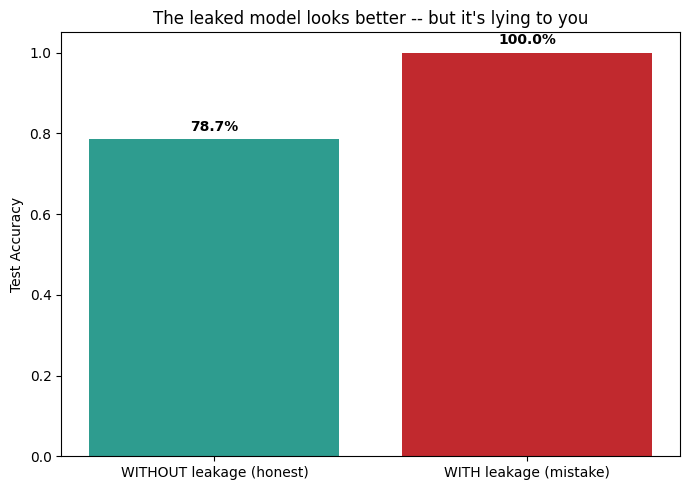

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(comparison["Model"], comparison["Test Accuracy"], color=["#2E9C8F", "#C1292E"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("The leaked model looks better -- but it's lying to you")
for bar, val in zip(bars, comparison["Test Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### Step 4 — Which feature is doing the damage?

In [7]:
from sklearn.preprocessing import StandardScaler

# Standardize first -- otherwise coefficient MAGNITUDE isn't comparable across features
# on different scales (this is the same lesson as Unit 1, Session 5's scaling topic)
scaler_leaked = StandardScaler()
X_train_lk_scaled = scaler_leaked.fit_transform(X_train_lk)

model_leaked_scaled = LogisticRegression(max_iter=1000).fit(X_train_lk_scaled, y_train_lk)

leaked_coefs = pd.DataFrame({
    "feature": X_leaked.columns,
    "coefficient": model_leaked_scaled.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)
leaked_coefs

,feature,coefficient
5,final_bill_amount,3.170246
3,days_since_cancellation,2.163417
4,retention_offer_after_cancellation,1.021609
7,contract_type_Two year,-0.520603
1,monthly_charges,-0.520400
6,contract_type_One year,-0.486792
0,tenure_months,-0.202293
2,support_calls,-0.109060


**What to notice:** the three leaked features (`final_bill_amount`, `days_since_cancellation`,
`retention_offer_after_cancellation`) should have coefficients several times LARGER than any
legitimate feature — often 3-6x the size of `monthly_charges` or `contract_type`, even though
all features were standardized to the same scale first. The model has essentially learned "if
these leak columns are not -1/0, predict churn," which is just reading the leak, not learning
genuine churn behavior at all.

### Why this model fails in production

On the day you actually need a prediction — BEFORE a customer has decided anything —
`days_since_cancellation` is `-1` for every single customer (nobody has cancelled yet, so
nobody has a cancellation date). The "amazing" model that scored 100% in testing has now lost
its only real signal and collapses back to guessing — except now it's guessing badly, because
it never bothered to learn from the legitimate features (`tenure_months`, `support_calls`,
etc.) in the first place. The retention team ends up with a model that is actively **worse**
than the honest one, while everyone believed — based on the validation report — that it was
essentially perfect.

## Industry Case Study

**Banking — loan default prediction.** A bank builds a model to predict whether a loan
applicant will default, using every column available in the loan servicing database. Buried in
there is `days_past_due_at_writeoff` — a field that is only populated once a loan has ALREADY
been written off as a default. The model, trained on this column, achieves 98% accuracy in
back-testing. It's deployed to score NEW applicants at the moment of application — when, by
definition, no loan has been disbursed yet, let alone gone into default. The field is blank for
every single new applicant, and the "98% accurate" model turns out to have almost no idea how
to separate genuinely risky applicants from safe ones, because it never really learned to.

```
RAW DATA                    FEATURE                        MODEL              BUSINESS DECISION
-----------------            -------------------            -----              ------------------
loan applications      -->   credit_score,             -->  predicts    -->   approve / decline
loan servicing table         income, existing_debt           default          the loan application
(incl. writeoff records)     ... AND ACCIDENTALLY
                              days_past_due_at_writeoff
                              (only exists post-default!)
```

This exact pattern — a "too good to be true" back-test driven by a field that only exists
downstream of the outcome — is one of the most common, most expensive mistakes in credit risk
modeling, fraud detection, insurance underwriting, and churn prediction alike.

## What Can Go Wrong?

Data leakage isn't one single mistake — it shows up in at least four different, common shapes.
Let's go through each with the same structure: **Problem → Why it happens → Example → How to
detect it → How to fix it.**

### 1. Target Leakage

**Problem:** a feature contains information that is a direct RESULT of the target, not a cause
or predictor of it.

**Why it happens:** databases often store outcome-related fields (cancellation records, final
bills, write-off dates) right next to genuinely predictive fields, in the same table, with no
obvious warning label distinguishing them.

**Example:** `days_since_cancellation`, `final_bill_amount`, `retention_offer_after_cancellation`
in our churn dataset above — every one of them is a RECORD of churn, not a predictor of it.

**How to detect it:** a feature with suspiciously high correlation to the target (we saw
`final_bill_amount` at r ≈ 0.91!) deserves immediate scrutiny — legitimate real-world features
are rarely THAT strongly correlated with a genuinely hard-to-predict outcome. Also check: does
this feature have a plausible business reason to be missing exactly when, and only when, the
target is one specific value?

**How to fix it:** remove the feature, or replace it with a version that only uses information
truly available at prediction time (e.g., `support_calls_last_30_days` computed as of TODAY,
not `support_calls_total` computed at the moment the account was closed).

### 2. Look-Ahead Bias (Temporal Leakage)

**Problem:** a feature is calculated using data that, chronologically, comes from AFTER the
point in time you're supposed to be making the prediction.

**Why it happens:** it's easy to compute an aggregate ("average transaction amount," "total
support calls") over "all available data" without stopping to check whether some of that data
is actually from the future relative to the prediction date.

**Example:** imagine engineering `total_support_calls` by counting EVERY support call in the
database for a customer — including calls they made complaining AFTER they'd already decided to
cancel. That feature is contaminated with information from after the moment you needed to
predict `churn`.

**How to detect it:** for every feature, ask: *"what specific DATE range of raw data went into
computing this number, and does any of that range fall after my prediction date?"*

**How to fix it:** always compute time-based aggregates using a strict cutoff — "only using
data available up to and including the prediction date," never a whole-history aggregate
computed without regard to timing.

### 3. Preprocessing Leakage

**Problem:** a preprocessing step (scaling, imputation, encoding) is fit using statistics from
the FULL dataset — including the test set — before the train/test split happens.

**Why it happens:** it's one line of code shorter to scale everything once, before splitting,
than to remember to split first and fit the scaler only on train. It's an easy, very common
shortcut to take by accident.

**Example:** `StandardScaler().fit(X)` on the whole dataset, THEN `train_test_split`. The
scaler's mean and standard deviation now include information from the test set, so your "test"
set isn't a clean, independent measurement of generalization anymore.

**How to detect it:** check the ORDER of operations in your code — does `fit()` or
`fit_transform()` ever get called before `train_test_split()`?

**How to fix it:** always split first, then `fit()` only on the training data, then
`transform()` (never `fit()`) on the test data. We demonstrate exactly this, side by side, in
the next section.

### 4. Train-Test Contamination

**Problem:** information from the test set leaks into model training through ANY channel —
not just preprocessing, but also duplicate rows across train/test, feature selection performed
on the full dataset before splitting, or hyperparameter tuning that peeks at test performance
repeatedly.

**Why it happens:** the train/test split is often treated as the LAST step of a pipeline,
after all the "real" data work is done — when it actually needs to be closer to the FIRST step.

**Example:** running correlation-based feature selection (Unit 2) on the full dataset, THEN
splitting into train/test. The test set has already influenced which features were kept.

**How to detect it:** ask, for every fitted object in your pipeline (scaler, imputer, encoder,
feature selector, model) — *"was this `.fit()` call given only training rows?"*

**How to fix it:** wrap every fittable step inside a single `sklearn.Pipeline` (Unit 1, Session
2), fit the WHOLE pipeline only on the training split, and let it `.transform()`/`.predict()`
the test split — never the reverse.

## Demonstration: Wrong vs. Correct Preprocessing Order

Let's make the preprocessing leakage mistake (#3 above) concrete with real numbers on our
churn dataset.

In [8]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["tenure_months", "monthly_charges", "support_calls"]
X_numeric = df[numeric_cols]

# ---------------------------------------------------------------------------
# WRONG: fit the scaler on the ENTIRE dataset, THEN split
# ---------------------------------------------------------------------------
scaler_wrong = StandardScaler().fit(X_numeric)                       # sees ALL rows, incl. future "test" rows
X_scaled_wrong = scaler_wrong.transform(X_numeric)
X_train_wrong, X_test_wrong = train_test_split(X_scaled_wrong, test_size=0.25, random_state=42)

print("WRONG -- scaler's mean, computed using the FULL dataset (train + test mixed together):")
print(scaler_wrong.mean_.round(3))

WRONG -- scaler's mean, computed using the FULL dataset (train + test mixed together):
[19.482 64.754  2.23 ]


In [9]:
# ---------------------------------------------------------------------------
# CORRECT: split FIRST, then fit the scaler on the TRAINING split ONLY
# ---------------------------------------------------------------------------
X_train_raw, X_test_raw = train_test_split(X_numeric, test_size=0.25, random_state=42)

scaler_correct = StandardScaler().fit(X_train_raw)                   # sees ONLY training rows
X_train_correct = scaler_correct.transform(X_train_raw)
X_test_correct = scaler_correct.transform(X_test_raw)                 # transform only -- never fit again

print("CORRECT -- scaler's mean, computed using TRAINING rows only:")
print(scaler_correct.mean_.round(3))

print("\nDifference between the two means:", (scaler_wrong.mean_ - scaler_correct.mean_).round(4))

CORRECT -- scaler's mean, computed using TRAINING rows only:
[19.32  65.033  2.269]

Difference between the two means: [ 0.1617 -0.279  -0.0389]


**The gap looks small here** — a few hundredths of a unit — because our synthetic dataset is
well-behaved and reasonably large. On smaller datasets, or datasets with more extreme values,
this same mistake produces a much bigger gap between "wrong" and "correct" statistics, and a
correspondingly more misleading validation score. **The size of the leak isn't the point — the
PRINCIPLE is:** the test set's job is to simulate genuinely unseen future data. The moment any
fitted statistic has seen test rows, that simulation is broken, even if the numeric damage
looks small today.

## Leakage Detection Checklist

Keep this checklist next to you for every project. Before trusting ANY validation score, work
through it:

- [ ] **The main question:** for every feature, could it have existed at the exact moment I need
      to make this prediction — not one second later?
- [ ] Does any feature have a suspiciously perfect (or near-perfect) correlation with the target?
- [ ] Does any feature's MISSINGNESS pattern line up suspiciously well with the target (e.g.,
      only missing when the target is 0, or only present when the target is 1)?
- [ ] For any time-based feature: what exact date range of raw data went into computing it, and
      could any of that range fall after the prediction date?
- [ ] Did I call `train_test_split()` BEFORE or AFTER fitting any scaler, imputer, encoder, or
      feature selector?
- [ ] Is every fitted preprocessing step wrapped inside a single `Pipeline`, fit only on the
      training data?
- [ ] Did my model's validation score jump unexpectedly high after adding a new feature? If so,
      that feature is the first suspect, not the first celebration.
- [ ] Would a domain expert (someone who actually works with this data day to day) agree that
      this feature is something we'd realistically have on hand at prediction time?

## Mini Exercise

**Try this yourself before looking at the solution.**

Below is a NEW, small dataset for a bank's loan default model. One of the columns is a leaked
feature. Identify it, explain WHY it's leaked, and explain what you'd do instead.

| customer_id | credit_score | annual_income | loan_amount | days_late_on_final_payment | defaulted |
|---|---|---|---|---|---|
| 1 | 710 | 62000 | 15000 | *(blank)* | 0 |
| 2 | 590 | 34000 | 22000 | 47 | 1 |
| 3 | 745 | 81000 | 10000 | *(blank)* | 0 |
| 4 | 605 | 29000 | 18000 | 62 | 1 |
| 5 | 680 | 55000 | 12000 | *(blank)* | 0 |

Which column is leaked, and why?

## Exercise Solution

**The leaked column is `days_late_on_final_payment`.**

**Why it's leaked:** this column records how late a customer's FINAL payment was — but there
only IS a "final payment" to be late on if the loan has already gone through its full repayment
history and (in this case) ended in default. A customer who is still actively repaying their
loan, or who paid it off successfully, doesn't have a "final payment" event in the same sense —
which is exactly why it's blank for every `defaulted = 0` row above. This column is a RECORD
that a default-related process already occurred, not a predictor available at loan approval
time.

**What to do instead:** remove `days_late_on_final_payment` entirely from the model. If "late
payment behavior" is a genuinely useful signal, look for a version that's available at
prediction time instead — e.g., `days_late_on_most_recent_payment_so_far`, computed using only
payment history up to TODAY, for a loan that's still active and hasn't been decided yet.

**The one-line test that catches it, every time:** *"Could `days_late_on_final_payment` exist
for a brand-new applicant who hasn't even received the loan yet?"* No — so it can't be used.

## Interview Questions

**1. (Conceptual) What is data leakage, in one sentence?**
> Data leakage is when information that would not genuinely be available at prediction time
> ends up in your training data, making the model's validation performance look better than it
> will actually perform in production.

**2. (Conceptual) What's the difference between target leakage and look-ahead bias?**
> Target leakage is a feature that's a direct RESULT of the outcome (e.g., a cancellation
> date). Look-ahead bias is a feature computed using data from a time period that's
> chronologically AFTER the prediction point, even if it's not directly derived from the
> target itself (e.g., an aggregate that accidentally includes future transactions).

**3. (Practical) You just added a feature and your model's accuracy jumped from 75% to 99%.
What do you do?**
> Treat this as a red flag, not a win. Check the new feature's correlation with the target, and
> ask whether it could realistically exist at the moment you need to make the prediction. A
> jump that large is far more often a leak than a genuine breakthrough.

**4. (Practical) What's wrong with `scaler.fit(X)` followed by `train_test_split(X, y)`?**
> The scaler has already seen the test rows before the split even happens, so its mean/std
> reflect information from data the model is supposed to have never seen. Always split first,
> then `fit()` only on the training data.

**5. (Scenario) A hospital wants to predict readmission risk at the time of discharge. A
data scientist includes `total_length_of_stay` as a feature. Is this leakage?**
> It depends on WHEN you need the prediction. If you need to predict readmission risk
> DURING the hospital stay (before discharge), `total_length_of_stay` isn't fully known yet and
> would be leakage. If you're predicting AFTER discharge has already happened, the total stay
> length is legitimately known and is not leakage. Always anchor the question to the exact
> prediction moment.

**6. (Scenario) Your team performs feature selection (picking the top 20 correlated features)
on the full dataset, then splits into train/test. Is this a problem?**
> Yes — this is train-test contamination. The feature selection step "saw" the test data's
> target values when deciding which features to keep, so the test set is no longer a clean,
> independent measurement.

**7. (Practical) How would you check a new dataset for target leakage before modeling?**
> Compute the correlation (or mutual information) of every feature against the target and
> flag anything suspiciously high; check missingness patterns against the target; and go
> through every feature asking "could this have existed at prediction time," ideally with
> input from someone who understands the business process that generated the data.

**8. (Conceptual) Why is a `Pipeline` object useful for preventing leakage?**
> A `Pipeline` bundles every preprocessing step and the model into one object that is fit ONLY
> on the data you explicitly give it. As long as you only ever call `.fit()` on the training
> split, every step inside the pipeline — imputers, scalers, encoders, the model — is
> guaranteed to have never seen the test data.

## Assignment (30-60 minutes)

You've been given a new dataset for an insurance company's fraud detection model:

| Column | Description |
|---|---|
| `policy_id` | Unique policy identifier |
| `policy_age_days` | How long the policy has existed |
| `claim_amount` | Amount claimed |
| `num_previous_claims` | Number of past claims by this policyholder |
| `investigator_assigned` | Whether a fraud investigator was assigned to review this claim |
| `claim_denied` | Whether the claim was ultimately denied |
| `is_fraud` | **Target** — was this claim fraudulent? |

**Your task:**
1. Load or construct a small version of this dataset (10-20 rows is fine — you can make up
   realistic values, following the patterns you've seen in this notebook).
2. Identify which column(s) are likely leaked, and explain why, using the "could this exist at
   prediction time" test.
3. Build TWO models: one using all columns, one using only the legitimate columns. Compare
   their accuracy and explain the gap in your own words.
4. Write one paragraph: what would you tell your manager if they asked why the "amazing"
   99%-accuracy fraud model can't actually be deployed as-is?

Do not just copy the code from this notebook — you should be able to explain your reasoning at
each step without looking back.

## Key Takeaways

- Data leakage is information from the future (or from the answer itself) sneaking into your
  training data — like giving a student the exam's answer key beforehand.
- The single most useful question you can ask about any feature: **"Could this have existed at
  the exact moment I need to make this prediction?"**
- A suspiciously perfect validation score is a red flag to investigate, not a result to celebrate.
- Leakage shows up in (at least) four shapes: target leakage, look-ahead bias, preprocessing
  leakage, and train-test contamination.
- Always split your data into train/test BEFORE fitting any preprocessing step — never after.
- Wrapping preprocessing + model inside a single `Pipeline`, fit only on the training split, is
  the most reliable structural defense against leakage.
- A model that "fails mysteriously" in production, after looking great in testing, should
  always trigger a leakage investigation first.

## Final Challenge

You're handed a dataset for a streaming service that wants to predict which subscribers will
**upgrade to a premium plan next month**. The columns include: `account_age_days`,
`monthly_watch_hours`, `device_count`, `support_tickets_opened`, `premium_trial_started_date`,
`premium_features_used_count`, and the target `upgraded_to_premium`.

Using everything from this notebook:
1. Identify which column(s) you'd investigate for leakage first, and why.
2. Describe the exact test you'd run to CONFIRM whether your suspicion is correct (not just
   assert it).
3. Propose one corrected, leak-free version of any feature you flag as risky.
4. In 2-3 sentences, explain how you would structure your `Pipeline` to guarantee none of your
   preprocessing steps ever see the test set.